In [ ]:
!unzip FishDataset.zip -d /content/

Archive:  FishDataset.zip
   creating: /content/FishDataset/
   creating: /content/FishDataset/test/
   creating: /content/FishDataset/test/Anthias anthias/
  inflating: /content/FishDataset/test/Anthias anthias/anthias_anthias-1.jpg  
  inflating: /content/FishDataset/test/Anthias anthias/anthias_anthias-137.jpg  
  inflating: /content/FishDataset/test/Anthias anthias/anthias_anthias-140.jpg  
  inflating: /content/FishDataset/test/Anthias anthias/anthias_anthias-1700.jpg  
  inflating: /content/FishDataset/test/Anthias anthias/anthias_anthias-1701.jpg  
  inflating: /content/FishDataset/test/Anthias anthias/anthias_anthias-1702.jpg  
  inflating: /content/FishDataset/test/Anthias anthias/anthias_anthias-1703.jpg  
  inflating: /content/FishDataset/test/Anthias anthias/anthias_anthias-1704.jpg  
  inflating: /content/FishDataset/test/Anthias anthias/anthias_anthias-1705.jpg  
  inflating: /content/FishDataset/test/Anthias anthias/anthias_anthias-1706.jpg  
  inflating: /content/FishDa

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

train_dir = '/content/FishDataset/train'
test_dir = '/content/FishDataset/test'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(150, 150), batch_size=20, class_mode='categorical')

test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=(150, 150), batch_size=20, class_mode='categorical')

Found 175 images belonging to 5 classes.
Found 75 images belonging to 5 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(5, activation='softmax') # 5 classes for fish species
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,036,229 (72.62 MB)

 Trainable params: 19,036,229 (72.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(5, activation='softmax') # 5 classes for your bird species
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=30, # You can adjust this; usually 20-50 is good for 250 images
    validation_data=test_generator,
    validation_steps=test_generator.samples // test_generator.batch_size
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 591ms/step - accuracy: 0.2851 - loss: 4.9056 - val_accuracy: 0.3167 - val_loss: 1.5601
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5000 - loss: 1.4888 - val_accuracy: 0.3667 - val_loss: 1.4649
Epoch 3/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 211ms/step - accuracy: 0.4613 - loss: 1.3896 - val_accuracy: 0.5000 - val_loss: 1.3583
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4000 - loss: 1.3700 - val_accuracy: 0.4500 - val_loss: 1.3488
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 252ms/step - accuracy: 0.4648 - loss: 1.1843 - val_accuracy: 0.4167 - val_loss: 1.3406
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5000 - loss: 1.0817 - val_accuracy: 0.3833 - val_loss: 1.3967
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 239ms/step - accuracy: 0.5689 - loss: 0.9918 - val_accuracy: 0.4500 - val_loss: 1.4214
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5000 - loss: 1.1120 - val_accuracy: 0.4333 - val_loss: 1.3756
Epoch 9/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 374ms/step - accuracy: 0.6369 - loss: 0.9019 - val_accuracy: 0.4167 - val_loss: 1.2557
Epoch 10/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5500 - loss: 0.7805 - val_accuracy: 0.4500 - val_loss: 1.3397
Epoch 

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions
test_generator.reset()
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

# Print Classification Report (Precision, Recall, F1-score)
print('Classification Report')
target_names = list(test_generator.class_indices.keys())
print(classification_report(test_generator.classes, y_pred, target_names=target_names))

# Generate Confusion Matrix
print('Confusion Matrix')
print(confusion_matrix(test_generator.classes, y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step
Classification Report
                    precision    recall  f1-score   support

   Anthias anthias       0.30      0.20      0.24        15
     Belone belone       0.12      0.07      0.09        15
       Coris julis       0.21      0.27      0.24        15
Dasyatis centroura       0.21      0.27      0.24        15
 Scomber japonicus       0.21      0.27      0.24        15

          accuracy                           0.21        75
         macro avg       0.21      0.21      0.21        75
      weighted avg       0.21      0.21      0.21        75

Confusion Matrix
[[3 1 6 4 1]
 [2 1 4 2 6]
 [2 0 4 4 5]
 [2 4 2 4 3]
 [1 2 3 5 4]]


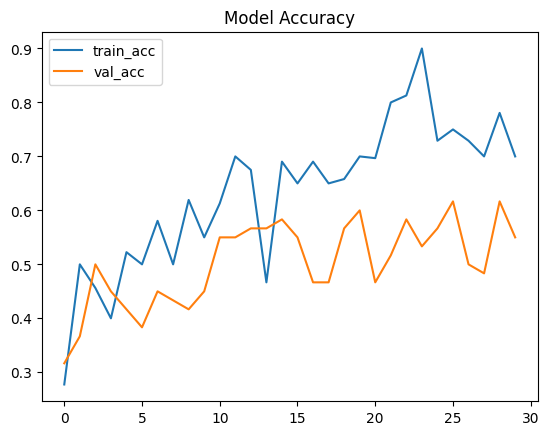

In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Model Accuracy')
plt.legend()
plt.show()

In [ ]:
model.save('fish_classifier_model.h5')

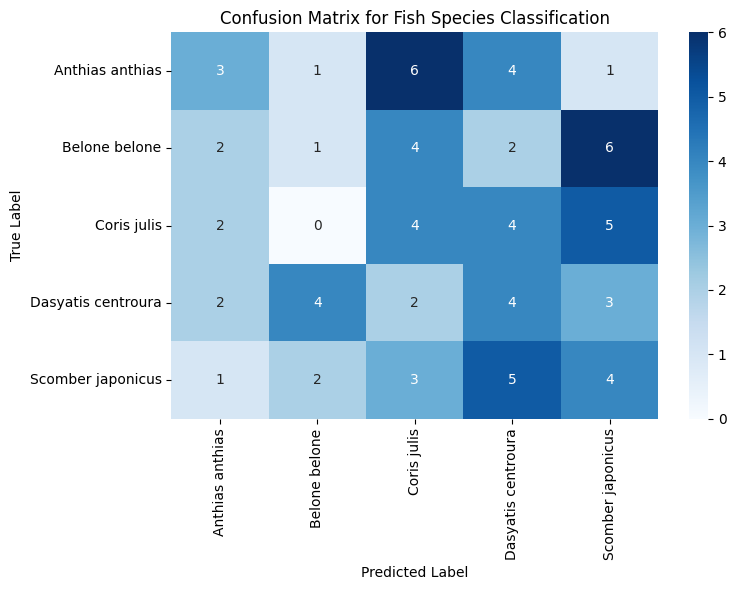

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get true labels from the test generator
y_true = test_generator.classes

# True and predicted labels
cm = confusion_matrix(y_true, y_pred)

class_names = [
    "Anthias anthias",
    "Belone belone",
    "Coris julis",
    "Dasyatis centroura",
    "Scomber japonicus"
]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Fish Species Classification")
plt.tight_layout()
plt.show()